# 03 · Comparable companies

**Question.** Where does a company sit relative to its peers on operating metrics, capital structure and valuation, and how much can a peer group of four support?

Uses `src/analytics/comps.py`, the same functions as the pipeline, the app and the Excel export.

*FinSight is an analytics tool, not investment advice.*

## 1. Data

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import text

from src.database import queries
from src.database.connection import get_engine
from src.formatting import format_crore, format_metric, format_pct

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})
ACCENT, GREY = "#1f4e79", "#8c8c8c"

with get_engine().connect() as conn:
    companies = queries.load_companies(conn)
    metrics = queries.load_metrics(conn)
    statements = queries.load_statements(conn)
    prices = queries.load_prices(conn)
    as_of = queries.load_latest_price_date(conn).iloc[0]["latest"]
firms = companies[companies["entity_type"] == "company"].reset_index(drop=True)
short = lambda t: t.replace(".NS", "")
print(f"{len(firms)} companies in {firms['sector_name'].nunique()} sectors | "
      f"{len(metrics):,} stored metric rows | prices to {as_of}")

25 companies in 5 sectors | 6,146 stored metric rows | prices to 2026-10-06


## 2. Method

- Peers: the other companies in the target's `peer_group`.
- The target is excluded from every statistic; a peer whose metric is N/A is left out.
- With four or more peers: min, P25, median, mean, P75, max and a percentile. With fewer: min, median, max and a rank.
- Percentage metrics are compared in percentage points; multiples as a relative premium.

In [2]:
from src.analytics import comps
from src.analytics.registry import REGISTRY

groups = firms.groupby("peer_group")["ticker"].apply(lambda s: ", ".join(short(t) for t in s))
print(groups.to_string())
TARGET = "TCS.NS"
result = comps.compare(metrics, companies, TARGET)
print(f"\nTarget {TARGET}; peers: {[short(p) for p in result['peers']]}; "
      f"warnings: {result['warnings'] or 'none'}")

peer_group
auto              BAJAJ-AUTO, M&M, MARUTI, HEROMOTOCO, EICHERMOT
banks             HDFCBANK, ICICIBANK, AXISBANK, KOTAKBANK, SBIN
consumer       HINDUNILVR, ITC, ASIANPAINT, NESTLEIND, BRITANNIA
it_services                     TCS, INFY, HCLTECH, WIPRO, TECHM
pharma                SUNPHARMA, CIPLA, DRREDDY, LUPIN, DIVISLAB

Target TCS.NS; peers: ['INFY', 'HCLTECH', 'WIPRO', 'TECHM']; warnings: none


## 3. Results

### 3.1 The comps tables

In [3]:
def show(target, category):
    table = comps.comps_table(metrics, companies, target, comps.default_peers(companies, target),
                              category)
    out = pd.DataFrame(index=[short(i) for i in table.index])
    for column in table.columns:
        unit = REGISTRY[column].unit
        out[comps.LABELS[column]] = [
            f"{int(v)}" if i == "Peer n" else ("–" if pd.isna(v) and str(i).startswith("Peer")
                                               else format_metric(v, unit))
            for i, v in table[column].items()]
    return out

for category in ("operating", "capital_structure", "valuation"):
    print(f"\n{category.replace('_', ' ').upper()} (peer rows exclude {short(TARGET)})")
    print(show(TARGET, category).to_string())


OPERATING (peer rows exclude TCS)
            revenue growth EPS growth gross margin EBITDA margin net margin    ROE    ROA FCF margin
TCS                   4.6%       1.4%        45.1%         27.1%      18.4%  48.7%  28.8%      18.0%
INFY                  4.6%       5.7%        30.2%         25.3%      16.4%  31.6%  19.6%      18.5%
HCLTECH              11.2%      -4.3%        47.0%         21.0%      12.8%  23.0%  15.0%      14.3%
WIPRO                 4.0%       0.6%        29.2%         22.7%      14.2%  15.4%   9.8%      14.4%
TECHM                 7.2%      13.1%        28.2%         15.5%       8.5%  16.9%  10.3%       9.6%
Peer n                   4          4            4             4          4      4      4          4
Peer min              4.0%      -4.3%        28.2%         15.5%       8.5%  15.4%   9.8%       9.6%
Peer p25              4.4%      -0.6%        28.9%         19.6%      11.7%  16.5%  10.1%      13.1%
Peer median           5.9%       3.2%        29.7%      

### 3.2 The target is excluded from its own peer statistics

In [4]:
row = next(r for r in result["rows"] if r["metric_name"] == "ev_ebitda")
peer_values = pd.Series(row["peer_values"]).dropna()
with_target = pd.concat([peer_values, pd.Series({TARGET: row["target_value"]})])
print("Peer EV/EBITDA:", {short(k): round(v, 2) for k, v in peer_values.items()})
print(f"Target: {row['target_value']:.2f}")
print(f"Peer median excluding the target: {peer_values.median():.2f}  (stored: "
      f"{row['peer_median']:.2f})")
print(f"Median if the target were wrongly included: {with_target.median():.2f}")
print(f"Premium to the peer median: {row['premium_pct']:+.1f}%   Position: {row['position_label']}")

Peer EV/EBITDA: {'INFY': 8.38, 'HCLTECH': 11.0, 'WIPRO': 6.68, 'TECHM': 14.82}
Target: 10.11
Peer median excluding the target: 9.69  (stored: 9.69)
Median if the target were wrongly included: 10.11
Premium to the peer median: +4.4%   Position: 50th percentile


### 3.3 Positioning and the generated text

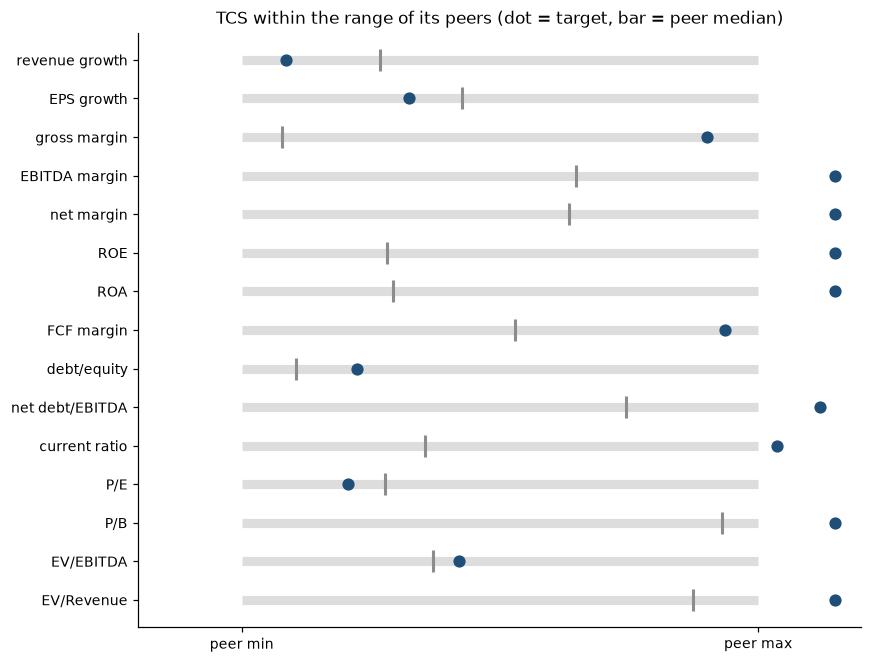

- Tata Consultancy Services' revenue growth of 4.6% is 1.3 percentage points below the peer median of 5.9% (n=4). Growth for INFY.NS is reporting-currency growth (USD).
- Tata Consultancy Services' EPS growth of 1.4% is 1.8 percentage points below the peer median of 3.2% (n=4). Growth for INFY.NS is reporting-currency growth (USD).
- Tata Consultancy Services' gross margin of 45.1% is 15.4 percentage points above the peer median of 29.7% (n=4).
- Tata Consultancy Services' EBITDA margin of 27.1% is 5.2 percentage points above the peer median of 21.9% (n=4).
- Tata Consultancy Services' net margin of 18.4% is 4.9 percentage points above the peer median of 13.5% (n=4).
- Tata Consultancy Services' ROE of 48.7% is 28.8 percentage points above the peer median of 19.9% (n=4).
- Tata Consultancy Services' ROA of 28.8% is 16.1 percentage points above the peer median of 12.6% (n=4).
- Tata Consultancy Services' FCF margin of 18.0% is 3.6 percentage points above the peer median of 14.3% (n=4).


In [5]:
rows = [r for r in result["rows"] if r["target_value"] is not None and r["n_peers"] > 0
        and r["peer_max"] != r["peer_min"]]
fig, ax = plt.subplots(figsize=(8, 0.34 * len(rows) + 1))
for i, r in enumerate(rows):
    span = r["peer_max"] - r["peer_min"]
    ax.plot([0, 1], [i, i], color="#dddddd", lw=6, solid_capstyle="butt")
    ax.plot((r["peer_median"] - r["peer_min"]) / span, i, "|", color=GREY, ms=14, mew=2)
    ax.plot(np.clip((r["target_value"] - r["peer_min"]) / span, -0.15, 1.15), i, "o",
            color=ACCENT, ms=7)
ax.set_yticks(range(len(rows)), [comps.LABELS[r["metric_name"]] for r in rows])
ax.set_xticks([0, 1], ["peer min", "peer max"]); ax.set_xlim(-0.2, 1.2); ax.invert_yaxis()
ax.grid(False); ax.set_title(f"{short(TARGET)} within the range of its peers "
                             "(dot = target, bar = peer median)")
plt.tight_layout(); plt.show()
for sentence in result["interpretation"]:
    print("-", sentence)

### 3.4 When fewer than four peers have a value

In [6]:
small = comps.compare(metrics, companies, "HINDUNILVR.NS")
table = pd.DataFrame([{
    "metric": comps.LABELS[r["metric_name"]], "n": r["n_peers"],
    "min": r["peer_min"], "p25": r["peer_p25"], "median": r["peer_median"],
    "mean": r["peer_mean"], "p75": r["peer_p75"], "max": r["peer_max"],
    "position": r["position_label"]} for r in small["rows"]
    if r["metric_name"] in ("revenue_growth", "net_margin", "roe", "pe_ratio", "ev_ebitda")])
print("Hindustan Unilever (consumer). Nestle India has no FY2026 income statement at source,")
print("so operating metrics have three peers with a value; valuation has four.")
print(table.round(3).to_string(index=False))
stored = pd.read_sql(text("""SELECT n_peers, count(*) AS comparisons FROM core.peer_comparisons
                             GROUP BY 1 ORDER BY 1"""), get_engine())
print("\nStored default-peer comparisons by number of peers with a value:")
print(stored.to_string(index=False))

Hindustan Unilever (consumer). Nestle India has no FY2026 income statement at source,
so operating metrics have three peers with a value; valuation has four.
        metric  n    min    p25  median   mean    p75    max        position
revenue growth  3  0.048    NaN   0.051    NaN    NaN  0.075        2nd of 4
    net margin  3  0.122    NaN   0.134    NaN    NaN  0.265        2nd of 4
           ROE  3  0.212    NaN   0.290    NaN    NaN  0.535        2nd of 4
           P/E  4 16.153 38.051  47.062 47.063 56.074 77.978 25th percentile
     EV/EBITDA  4 10.509 23.979  29.544 29.048 34.613 46.597 25th percentile

Stored default-peer comparisons by number of peers with a value:
 n_peers  comparisons
       0           40
       3           44
       4          291


### 3.5 How precisely is a peer median known?

In [7]:
intervals = pd.read_sql(text("""
    SELECT subject, statistic AS median, ci_low, ci_high, n FROM core.ml_stat_tests
    WHERE test = 'peer_median_bootstrap_ci' ORDER BY subject"""), get_engine())
pe = intervals[intervals["subject"].str.endswith("pe_ratio")].copy()
pe["width / median"] = (pe["ci_high"] - pe["ci_low"]) / pe["median"]
print("Bootstrap 95% intervals for each peer group's median P/E (five companies per group):")
print(pe.round(2).to_string(index=False))

Bootstrap 95% intervals for each peer group's median P/E (five companies per group):
               subject  median  ci_low  ci_high  n  width / median
       auto | pe_ratio   23.41   18.69    33.39  5            0.63
      banks | pe_ratio   15.56   10.62    22.28  5            0.75
   consumer | pe_ratio   45.35   16.15    77.98  5            1.36
it_services | pe_ratio   15.44   12.11    28.28  5            1.05
     pharma | pe_ratio   30.39   17.24    95.06  5            2.56


## 4. Interpretation

- The tables place the target next to each peer and summarize the peers below; the generated sentences restate those figures and nothing more.
- Excluding the target matters: the cell above shows the median with and without it.
- A peer median of four companies is loosely determined. The bootstrap intervals for P/E are wide relative to the medians themselves, so a premium or discount of a few percent is within noise.
- When a peer lacks a value the statistics shrink to min, median and max and position becomes a rank, which is the honest amount to report.

## 5. Limitations

- Four peers per company; peer groups were chosen by sector, not by business mix (Bajaj Auto makes two-wheelers, Maruti cars; ITC is a conglomerate).
- Peers are not on identical bases: some current multiples use trailing-twelve-month earnings and others the latest annual figure, and Infosys is translated from USD. The sentences say so where it applies.
- Operating metrics are for each company's latest fiscal year, a single year.
- Descriptive only: a lower multiple than the peer median is a statement about the numbers, not about value.

*FinSight is an analytics tool, not investment advice.*